In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection
from sklearn.model_selection import train_test_split

In [2]:
dataset_path = 'perfume_type_classification_dataset.csv'
df = pd.read_csv(dataset_path)
df

,longevity_hours,sillage_score,top_note_count,price_usd,concentration_percent,fragrance_family,brand_tier,gender_target,contains_alcohol,limited_edition,perfume_category
0,5.96,5.80,5,103.71,17.04,Floral,Designer,Men,0.0,0,Eau de Parfum
1,8.85,7.70,4,122.93,15.28,Oriental,Luxury,Men,1.0,0,Eau de Toilette
2,0.54,2.67,3,105.21,12.69,Fresh,Designer,Men,0.0,0,Eau de Toilette
3,9.83,8.06,7,165.64,20.95,Floral,Luxury,Women,1.0,0,Eau de Parfum
4,11.03,9.72,5,279.00,25.00,Oriental,Luxury,Women,1.0,0,Perfume Extract
...,...,...,...,...,...,...,...,...,...,...,...
69995,8.29,7.82,6,67.13,7.61,Citrus,Luxury,Men,1.0,0,Eau de Toilette
69996,5.92,3.82,6,71.81,11.16,Oriental,Niche,Women,1.0,0,Eau de Toilette
69997,7.55,5.13,5,23.56,18.84,Citrus,Drugstore,Women,1.0,0,Eau de Parfum
69998,3.09,7.37,5,71.07,21.56,Fresh,Drugstore,Men,1.0,0,Eau de Parfum


|name   | description|
|-------|------------|
|longevity_hours	|	How long the scent lasts|
|sillage_score	|	Scent trail/projection strength (1–10)|
|top_note_count	|	Number of top notes (fewer in stronger concentrations)|
|price_usd	|	Retail price|
|concentration_percent	|	Fragrance oil concentration (%)|
|fragrance_family	|	Floral / Woody / Oriental / Fresh / Citrus|
|brand_tier	|	Luxury / Designer / Niche / Drugstore|
|gender_target	|	Men / Women / Unisex|
|contains_alcohol	|	0/1 yes or no|
|limited_edition	|	0/1 yes or no|
|perfume_category	|	Eau de Cologne / Eau de Toilette / Eau de Parfum / Perfume Extract|

As we can see our dataset has 70k rows and 10 features as well as one target feature - perfume_category

In [3]:
df.describe()

,longevity_hours,sillage_score,top_note_count,price_usd,concentration_percent,contains_alcohol,limited_edition
count,70000.000000,70000.000000,70000.000000,69272.000000,70000.000000,68251.000000,70000.000000
mean,5.702075,5.572562,5.366800,98.586296,13.467856,0.853350,0.122386
std,3.180509,2.452350,2.408247,69.429082,7.500726,0.353759,0.327733
min,0.500000,1.000000,1.000000,10.000000,1.500000,0.000000,0.000000
25%,3.360000,3.770000,4.000000,42.740000,7.820000,1.000000,0.000000
50%,5.530000,5.580000,5.000000,89.700000,12.910000,1.000000,0.000000
75%,7.810000,7.390000,7.000000,141.902500,18.410000,1.000000,0.000000
max,16.000000,10.000000,10.000000,428.130000,35.000000,1.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longevity_hours        70000 non-null  float64
 1   sillage_score          70000 non-null  float64
 2   top_note_count         70000 non-null  int64  
 3   price_usd              69272 non-null  float64
 4   concentration_percent  70000 non-null  float64
 5   fragrance_family       70000 non-null  object 
 6   brand_tier             66497 non-null  object 
 7   gender_target          70000 non-null  object 
 8   contains_alcohol       68251 non-null  float64
 9   limited_edition        70000 non-null  int64  
 10  perfume_category       70000 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 5.9+ MB


#### Cleaning and exploring features

In [5]:
df.duplicated().sum()

np.int64(15000)

In [6]:
df = df.drop_duplicates()
df.isnull().sum()

longevity_hours             0
sillage_score               0
top_note_count              0
price_usd                 550
concentration_percent       0
fragrance_family            0
brand_tier               2750
gender_target               0
contains_alcohol         1375
limited_edition             0
perfume_category            0
dtype: int64

In [7]:
X = df.drop(columns='perfume_category')
y = df['perfume_category']

In [8]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [9]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [11]:
cat_cols = [name for name in X.columns if X[name].dtype == object]
num_cols = [name for name in X.columns if X[name].dtype == float or df[name].dtype == int]

In [21]:
df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].median())
df.loc[:, cat_cols] = df[cat_cols].fillna('Unknown')

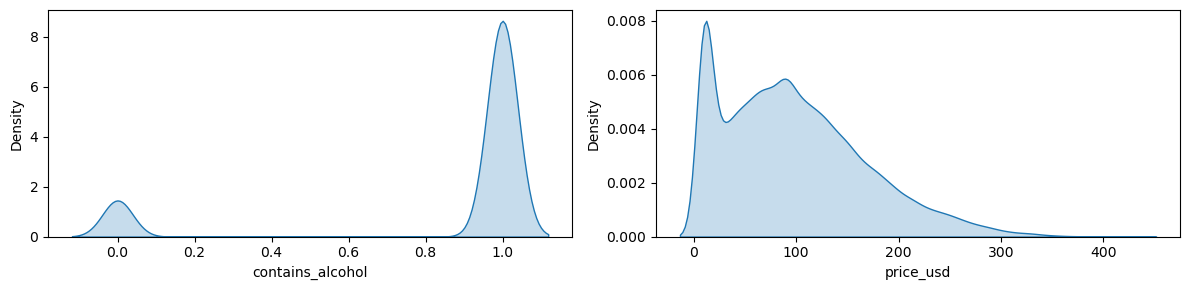

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.kdeplot(data=df, x = df['contains_alcohol'], ax=axes[0], fill = True)
sns.kdeplot(data=df, x = df['price_usd'], ax=axes[1], fill = True)
plt.tight_layout()
plt.show()

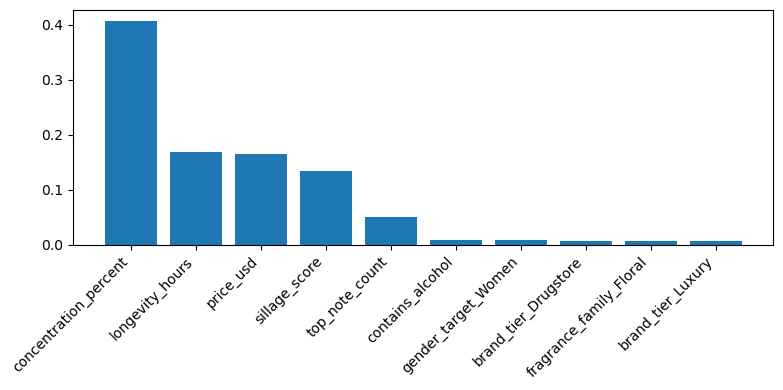

In [14]:
X_temp = pd.get_dummies(X, columns=cat_cols, drop_first=True)
rf_for_features = RandomForestClassifier(random_state=42)
rf_for_features.fit(X_temp, y)
importances = rf_for_features.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), X_temp.columns[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

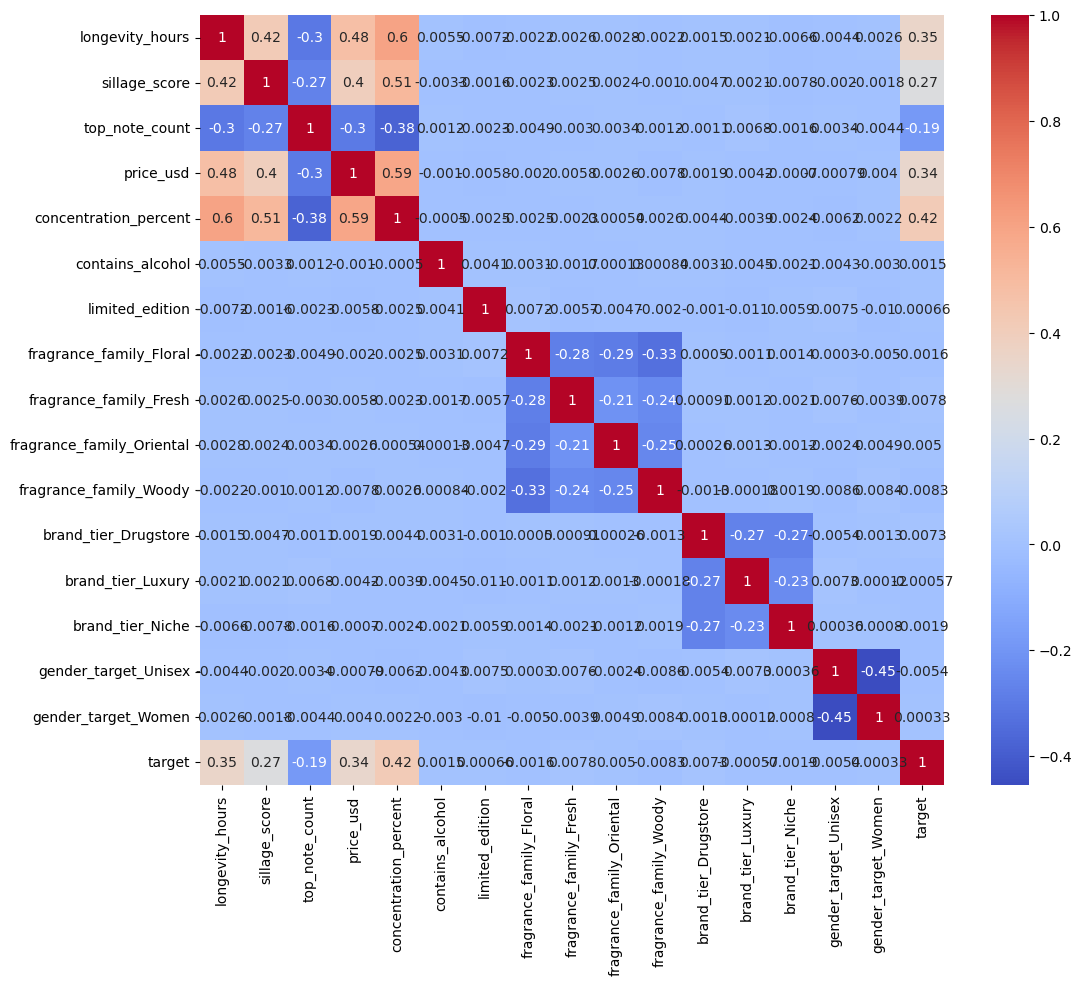

In [15]:
plt.figure(figsize=(12, 10))
corr_df = X_temp
corr_df['target']=y
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Lets get to plottin'

<Axes: ylabel='concentration_percent'>

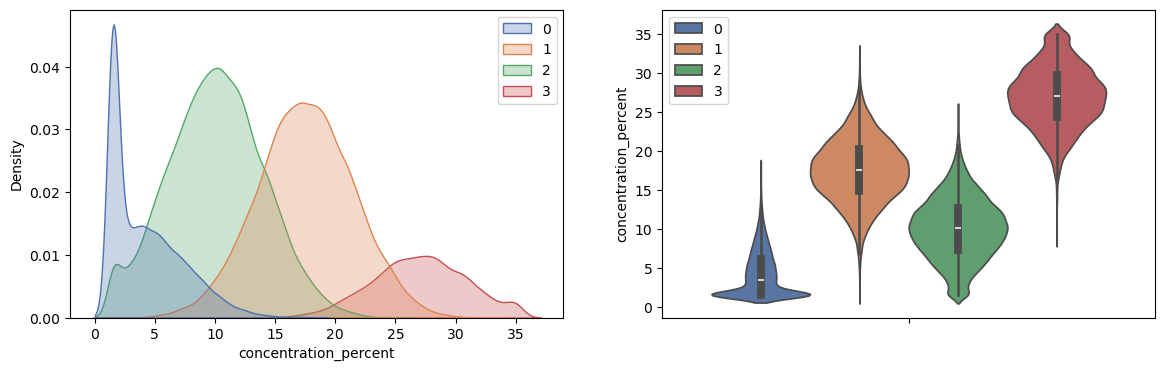

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(x=X_temp['concentration_percent'], hue=y, fill=True, alpha = 0.3, palette='deep', ax=axes[0])
sns.violinplot(y=X_temp['concentration_percent'], hue = y, palette='deep', ax=axes[1])

<Axes: ylabel='longevity_hours'>

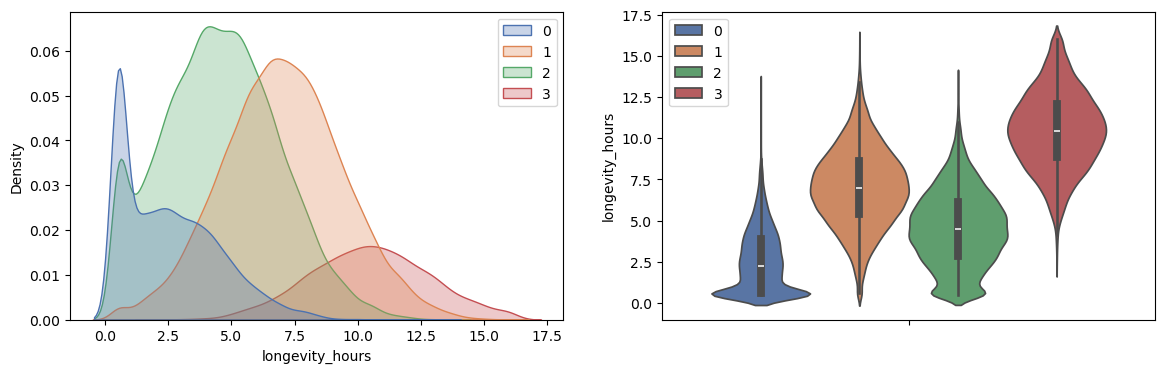

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(x=X_temp['longevity_hours'], hue=y, fill=True, alpha = 0.3, palette='deep', ax=axes[0])
sns.violinplot(y=X_temp['longevity_hours'], hue = y, palette='deep', ax=axes[1])

<Axes: xlabel='price_usd'>

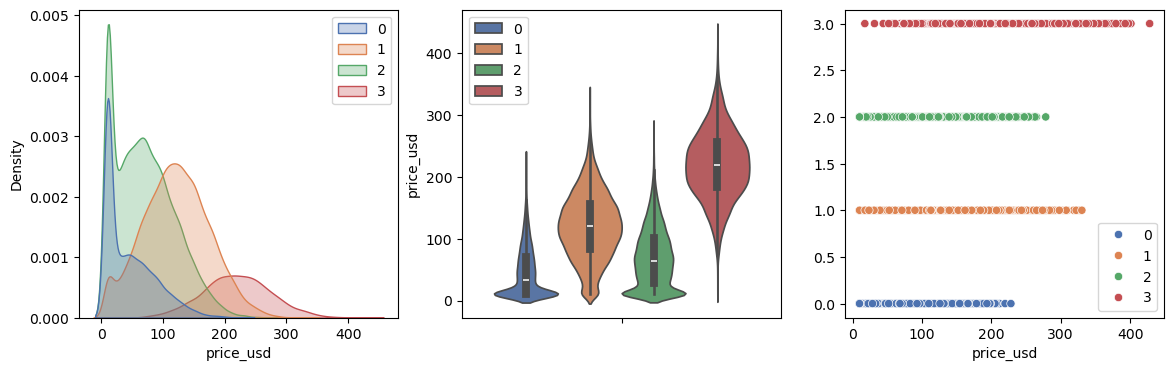

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.kdeplot(x=X_temp['price_usd'], hue=y, fill=True, alpha = 0.3, palette='deep', ax=axes[0])
sns.violinplot(y=X_temp['price_usd'], hue = y, palette='deep', ax=axes[1])
sns.scatterplot(x=X_temp['price_usd'], y = y, hue = y, palette='deep', ax=axes[2])


<Axes: ylabel='sillage_score'>

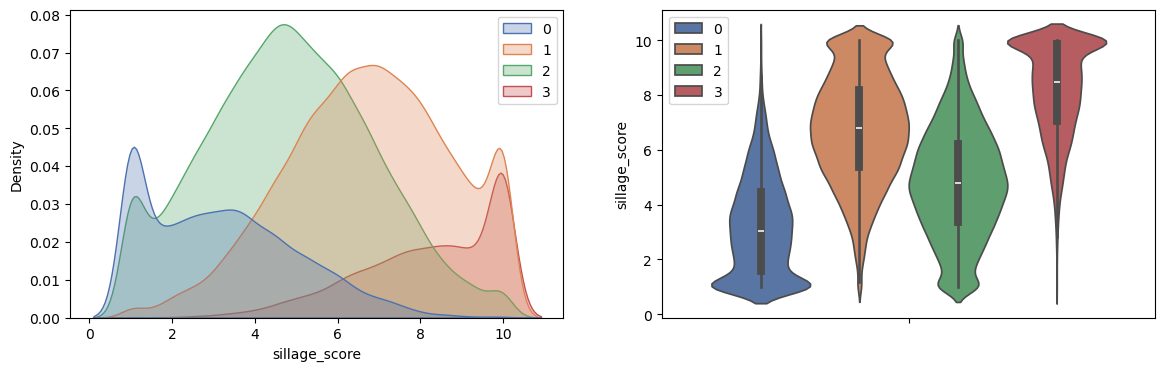

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(x=X_temp['sillage_score'], hue=y, fill=True, alpha = 0.3, palette='deep', ax=axes[0])
sns.violinplot(y=X_temp['sillage_score'], hue = y, palette='deep', ax=axes[1])


#### Making data more balanced by adding our SMOTE realisation (why tho...)

In [36]:
def manual_smote(X, y, target_class, oversampling_rate=1.0, k_neighbors=5):
    """
    X: np.array (матрица признаков)
    y: np.array (вектор целевой переменной)
    target_class: класс, который нужно догенерировать 
    oversampling_rate: коэффициент генерации (1.0 = увеличить выборку в 2 раза)
    k_neighbors: количество ближайших соседей для анализа
    """
    X = np.asarray(X)
    y = np.asarray(y)
    minority_samples = X[y == target_class]
    n_samples, n_features = minority_samples.shape

    if n_samples <= k_neighbors:
        raise ValueError(
            f"Количество объектов миноритарного класса ({n_samples}) "
            f"должно быть больше k_neighbors ({k_neighbors})."
        )

    n_synthetic = int(n_samples * oversampling_rate)
    synthetic_samples = np.empty((n_synthetic, n_features))

    for i in range(n_synthetic):
        base_idx = np.random.randint(0, n_samples)
        base_sample = minority_samples[base_idx]
        distances = np.linalg.norm(minority_samples - base_sample, axis=1)

        # Берем индексы k+1 ближайших (первый — это сам объект, расстояние 0)
        # Исключаем сам объект [1:] и случайно выбираем одного из k соседей
        nn_indices = np.argsort(distances)[1 : k_neighbors + 1]
        chosen_neighbor_idx = np.random.choice(nn_indices)
        neighbor_sample = minority_samples[chosen_neighbor_idx]

        # Генерация точки на отрезке между базовым объектом и соседом
        # Случайное число от 0 до 1 определяет положение новой точки
        gap = np.random.rand()
        synthetic_samples[i] = base_sample + gap * (
            neighbor_sample - base_sample
        )

    # Объединяем исходные данные с новыми синтетическими
    X_balanced = np.vstack((X, synthetic_samples))
    y_synthetic = np.full(n_synthetic, target_class)
    y_balanced = np.concatenate((y, y_synthetic))

    return X_balanced, y_balanced


In [37]:
df['perfume_category'].value_counts()

perfume_category
Eau de Toilette    22014
Eau de Parfum      19254
Eau de Cologne      8258
Perfume Extract     5474
Name: count, dtype: int64

In [38]:
print(list(target_encoder.classes_).index('Eau de Cologne'))
print(list(target_encoder.classes_).index('Perfume Extract'))


0
3


In [39]:
X_res, y_res = manual_smote(
    X, y, target_class=0, oversampling_rate=1.0, k_neighbors=3
)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [20]:
categorical_pipe = Pipeline(steps=[
    ('cat_imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('one_hot_encoderm', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numerical_pipe = Pipeline(steps=[
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
